In [ ]:
# ===================== Objective 1: Early Signal Detection (with visuals) =====================
# - Cleans data, builds weak triage labels
# - Baselines: TF-IDF + Multinomial LogReg (post-only vs post+comments)
# - Transformer triage: BERT (toggleable)
# - Visuals: label distribution, confusion matrices, PR curve (crisis), calibration (crisis),
#            top features for CRISIS (from LogReg coefficients)
# - Prints concise RQ1 interpretation

import os, re, glob, json, random, math
import numpy as np
import pandas as pd
from datetime import datetime

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

# ---------------- Config ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_DIR = "/kaggle/input/mentalhealthdata"      
PATTERN  = "*.csv"
LOWERCASE_LABELS = True
TRAIN_BERT = True                                # set False to skip transformer training
MAX_SAMPLES = None                               # e.g., 8000 to cap for quick runs; None = use all

# ------------- Utilities & helpers -------------
def print_header(title):
    bar = "=" * len(title)
    print(f"\n{title}\n{bar}")

def clean_text(s):
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return "" if s.lower()=="nan" else s

def coerce_datetime(col):
    num = pd.to_numeric(col, errors="coerce")
    dt_from_epoch = pd.to_datetime(num, unit="s", errors="coerce")
    dt_from_str   = pd.to_datetime(col, errors="coerce")
    return dt_from_epoch.fillna(dt_from_str)

def map_file_to_class(files):
    raw_labels = []
    for p in files:
        base = os.path.basename(p)
        stem = os.path.splitext(base)[0]
        token = stem.split("_", 1)[0] if "_" in stem else stem
        token = token.strip().lower() if LOWERCASE_LABELS else token.strip()
        raw_labels.append(token)
    labels, seen = [], {}
    for lab in raw_labels:
        if lab not in seen:
            seen[lab] = 1; labels.append(lab)
        else:
            seen[lab] += 1; labels.append(f"{lab}_{seen[lab]}")
    return labels

def load_and_clean(data_dir=DATA_DIR, pattern=PATTERN, max_samples=MAX_SAMPLES):
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files:
        raise FileNotFoundError(f"No CSV files in {data_dir} matching {pattern}")
    classes = map_file_to_class(files)

    frames = []
    for p, lab in zip(files, classes):
        df = pd.read_csv(p)
        df.insert(0, "condition_label", lab)
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)

    # Ensure expected columns exist
    keep_cols = ["condition_label","Title","Text","Top_10_Comments","Upvotes","Created_At","Author"]
    for c in keep_cols:
        if c not in df.columns:
            df[c] = np.nan

    for c in ["Title","Text","Top_10_Comments","Author","Created_At"]:
        df[c] = df[c].astype(str).map(clean_text)

    df["created_dt"] = coerce_datetime(df["Created_At"])
    df["post_only_text"] = (df["Title"] + " " + df["Text"]).map(clean_text).str.lower()
    df["context_text"]   = (df["post_only_text"] + " " + df["Top_10_Comments"]).map(clean_text).str.lower()

    # minimal filters
    df["token_cnt"] = df["context_text"].str.split().str.len()
    df = df[(df["context_text"]!="") & (df["token_cnt"]>3)].copy()

    # deduplicate
    df["_dup_key"] = df["context_text"].str.lower()
    df = df.drop_duplicates(subset=["_dup_key"]).drop(columns=["_dup_key"])

    df["Upvotes"] = pd.to_numeric(df["Upvotes"], errors="coerce").astype("Int64")

    if isinstance(max_samples, int) and len(df) > max_samples:
        df = df.sample(max_samples, random_state=SEED).reset_index(drop=True)

    return df.reset_index(drop=True)

# Weak triage labels (bootstrap)
kw_crisis = [
    "suicide","kill myself","end my life","want to die","self harm","self-harm",
    "overdose","can't go on","i'm done","ending it","hurt myself","hang myself"
]
kw_red = [
    "hopeless","no way out","worthless","can't cope","severe","cutting","relapse",
    "panic attack","shaking","numb","empty all the time","voice telling me","visions"
]
kw_amber = [
    "anxious","anxiety","depressed","depression","overwhelmed","crying",
    "can't sleep","insomnia","very stressed","please help","need help","advice please"
]
def make_weak_triage(text_series):
    text = text_series.fillna("").astype(str).str.lower()
    pat_crisis = re.compile("|".join([re.escape(k) for k in kw_crisis]))
    pat_red    = re.compile("|".join([re.escape(k) for k in kw_red]))
    pat_amber  = re.compile("|".join([re.escape(k) for k in kw_amber]))
    has_crisis = text.str.contains(pat_crisis, na=False)
    has_red    = text.str.contains(pat_red, na=False)
    has_amber  = text.str.contains(pat_amber, na=False)
    triage = np.where(has_crisis, "crisis",
              np.where(has_red,    "red",
              np.where(has_amber,  "amber", "green")))
    return pd.Series(triage, index=text.index)

def pr_curve_for_label(y_true, y_proba, labels, positive_label):
    """Returns precision, recall arrays for positive_label (one-vs-rest)."""
    if positive_label not in labels:
        return None, None, None
    pos_idx = labels.index(positive_label)
    y_true_bin = (np.array(y_true) == positive_label).astype(int)
    precision, recall, thr = precision_recall_curve(y_true_bin, y_proba[:, pos_idx])
    ap = average_precision_score(y_true_bin, y_proba[:, pos_idx])
    return precision, recall, ap

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    labs = sorted(list(pd.unique(np.concatenate([y_true, y_pred]))))
    cm = confusion_matrix(y_true, y_pred, labels=labs)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(range(len(labs)), labs, rotation=45)
    plt.yticks(range(len(labs)), labs)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def plot_pr(precision, recall, ap, title_prefix="PR Curve (crisis)"):
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision)
    plt.title(f"{title_prefix} | AP={ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.tight_layout(); plt.show()

def plot_calibration(y_true, y_proba, labels, positive_label, n_bins=10, title="Calibration: crisis"):
    if positive_label not in labels:
        return
    pos_idx = labels.index(positive_label)
    p = y_proba[:, pos_idx]
    y = (np.array(y_true) == positive_label).astype(int)
    # bin by predicted prob
    bins = np.linspace(0.0, 1.0, n_bins+1)
    inds = np.digitize(p, bins) - 1
    xs, ys = [], []
    for b in range(n_bins):
        mask = inds == b
        if mask.any():
            xs.append(p[mask].mean())
            ys.append(y[mask].mean())
    if len(xs) == 0:
        return
    plt.figure(figsize=(5.5,5.5))
    plt.plot([0,1],[0,1])
    plt.scatter(xs, ys)
    plt.title(title)
    plt.xlabel("Predicted probability"); plt.ylabel("Empirical positive rate")
    plt.tight_layout(); plt.show()

def show_top_features_for_class(vectorizer, clf, class_name, topk=15, title_prefix="Top features for"):
    if not hasattr(clf, "coef_"):
        print("Top features: classifier has no coefficients.")
        return
    classes = clf.classes_.tolist()
    if class_name not in classes:
        print(f"Class {class_name} not found.")
        return
    idx = classes.index(class_name)
    coef = clf.coef_[idx]
    feats = np.array(vectorizer.get_feature_names_out())
    top_pos_idx = np.argsort(coef)[-topk:]
    top_feats = feats[top_pos_idx]
    top_vals  = coef[top_pos_idx]
    order = np.argsort(top_vals)
    plt.figure(figsize=(7,5))
    plt.barh(range(len(order)), top_vals[order])
    plt.yticks(range(len(order)), top_feats[order])
    plt.title(f"{title_prefix} {class_name}")
    plt.tight_layout(); plt.show()


In [3]:
# ----------------- Load & label -----------------
df = load_and_clean()
df["triage_label"] = make_weak_triage(df["context_text"])

# Optional cap for quick dev
if isinstance(MAX_SAMPLES, int) and len(df) > MAX_SAMPLES:
    df = df.sample(MAX_SAMPLES, random_state=SEED).reset_index(drop=True)

print_header("Data & Label Snapshot")
print(df[["condition_label","triage_label","Title"]].head(5).to_string(index=False))


Data & Label Snapshot
condition_label triage_label                                                                                                                                                                                                                                        Title
           adhd        green                                                                                                                                                                                                        My son's ADHD saved his sister's life
           adhd       crisis                                                                                                                                           Reminder: If you made it to adulthood with late diagnosed or untreated ADHD, you are a *survivor.*
           adhd        amber Children with higher IQ scores were diagnosed later with ADHD than those with lower scores. Children with higher cognitive abilities might be able to 

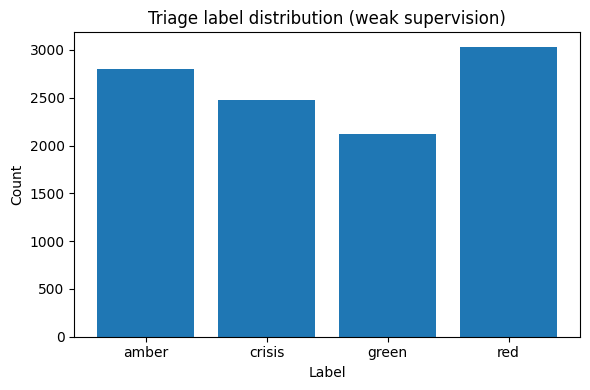


Classification Report — POST-ONLY (TF-IDF + LogReg)
              precision    recall  f1-score   support

       amber      0.492     0.507     0.500       560
      crisis      0.646     0.639     0.642       496
       green      0.455     0.607     0.520       425
         red      0.673     0.502     0.575       607

    accuracy                          0.557      2088
   macro avg      0.567     0.564     0.559      2088
weighted avg      0.574     0.557     0.560      2088

macro-F1=0.559 | crisis recall=0.639


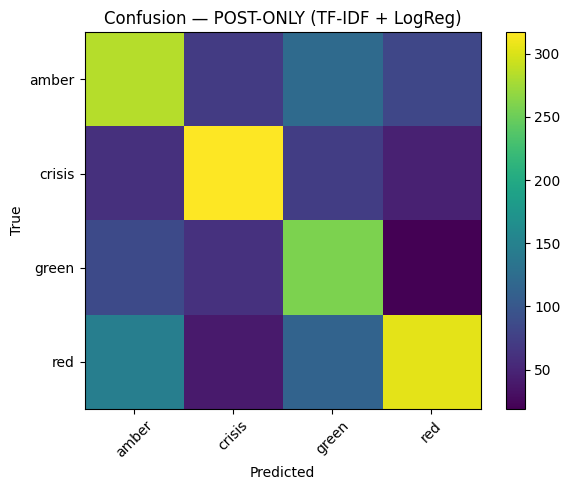

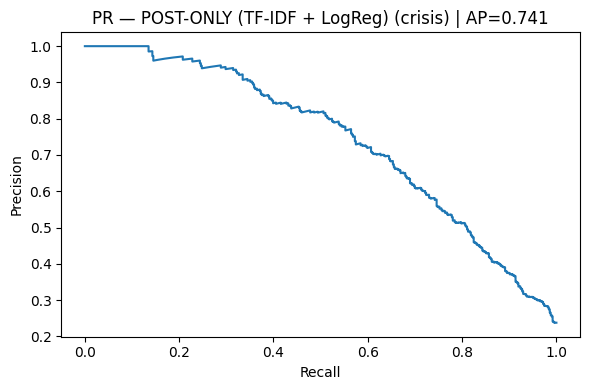

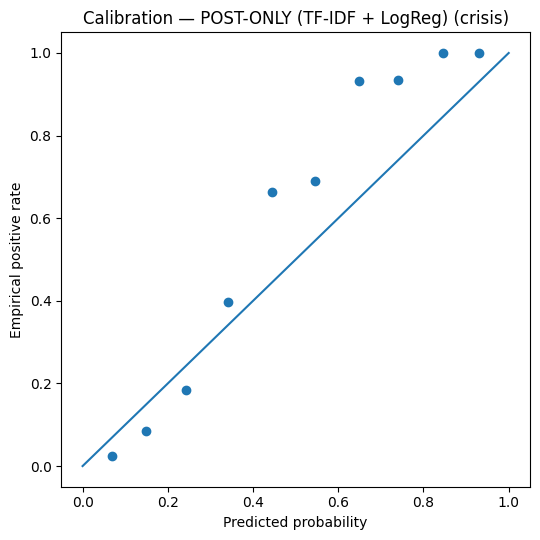

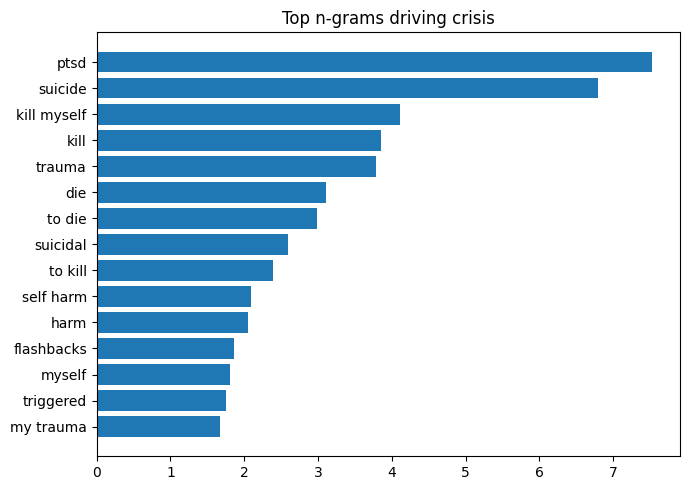


Classification Report — POST+COMMENTS (TF-IDF + LogReg)
              precision    recall  f1-score   support

       amber      0.615     0.632     0.623       560
      crisis      0.804     0.770     0.787       496
       green      0.589     0.760     0.664       425
         red      0.763     0.614     0.681       607

    accuracy                          0.686      2088
   macro avg      0.693     0.694     0.689      2088
weighted avg      0.698     0.686     0.687      2088

macro-F1=0.689 | crisis recall=0.770


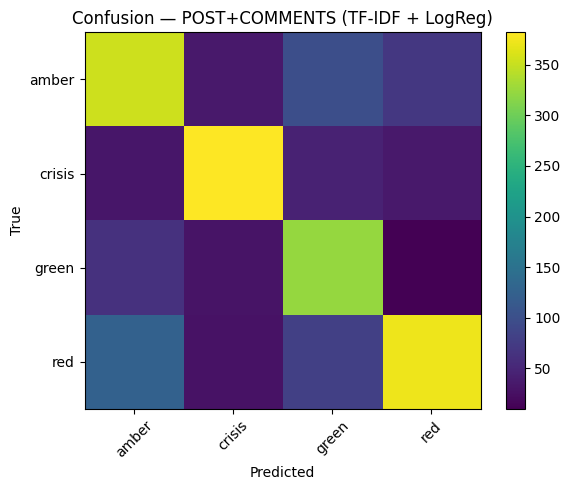

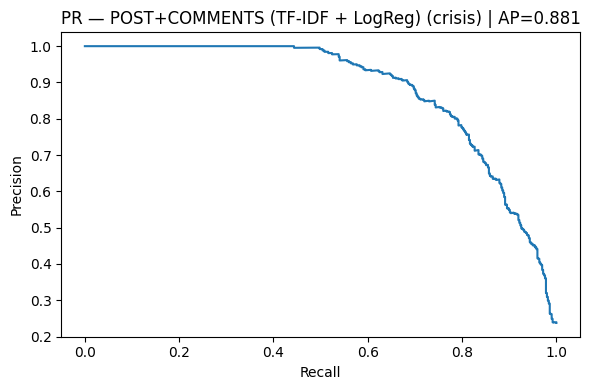

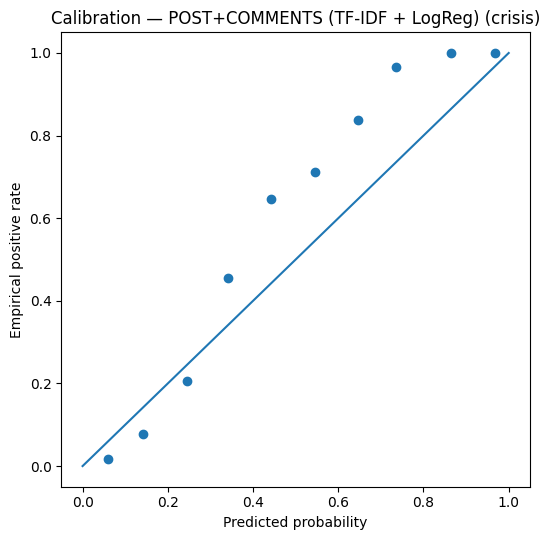

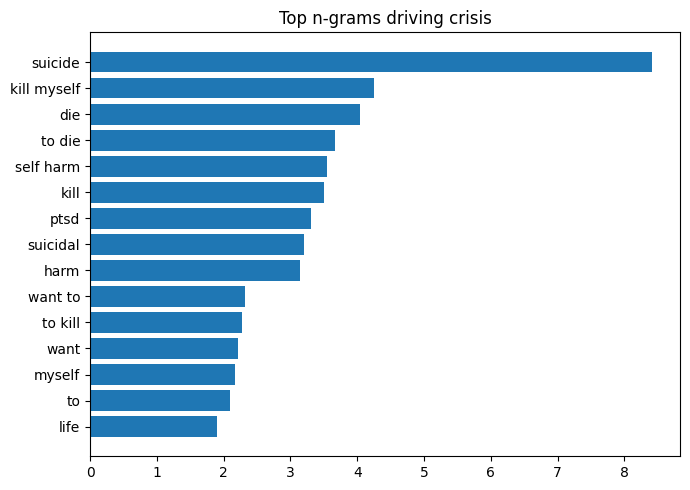

In [4]:
# Visual: triage label distribution
labs, cnts = np.unique(df["triage_label"], return_counts=True)
plt.figure(figsize=(6,4))
plt.bar(labs, cnts)
plt.title("Triage label distribution (weak supervision)")
plt.xlabel("Label"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

# ----------------- Baselines: post-only vs context -----------------
def train_eval_baseline(X_text, y_labels, title_note):
    X_tr, X_te, y_tr, y_te = train_test_split(X_text, y_labels, test_size=0.2, random_state=SEED, stratify=y_labels)
    vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=200_000)
    Xtr = vec.fit_transform(X_tr)
    Xte = vec.transform(X_te)
    classes = np.unique(y_tr)
    cw = compute_class_weight("balanced", classes=classes, y=y_tr)
    cw_map = {c:w for c,w in zip(classes, cw)}
    clf = LogisticRegression(
        solver="saga", multi_class="multinomial", penalty="l2",
        class_weight=cw_map, max_iter=3000, n_jobs=1, verbose=0
    ).fit(Xtr, y_tr)
    pred = clf.predict(Xte)
    print_header(f"Classification Report — {title_note}")
    print(classification_report(y_te, pred, digits=3))
    macro_f1 = f1_score(y_te, pred, average='macro')
    crisis_rec = recall_score((np.array(y_te)=="crisis").astype(int), (np.array(pred)=="crisis").astype(int))
    print(f"macro-F1={macro_f1:.3f} | crisis recall={crisis_rec:.3f}")
    plot_confusion(y_te, pred, title=f"Confusion — {title_note}")
    # PR + Calibration for crisis
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(Xte)
        labels = clf.classes_.tolist()
        pr, rc, ap = pr_curve_for_label(y_te, proba, labels, "crisis")
        if pr is not None:
            plot_pr(pr, rc, ap, title_prefix=f"PR — {title_note} (crisis)")
            plot_calibration(y_te, proba, labels, "crisis", title=f"Calibration — {title_note} (crisis)")
    # Top features for CRISIS (evidence)
    show_top_features_for_class(vec, clf, "crisis", topk=15, title_prefix="Top n-grams driving")
    return macro_f1, crisis_rec

m_f1_post, cri_post = train_eval_baseline(df["post_only_text"].values, df["triage_label"].values, "POST-ONLY (TF-IDF + LogReg)")
m_f1_ctx,  cri_ctx  = train_eval_baseline(df["context_text"].values,  df["triage_label"].values, "POST+COMMENTS (TF-IDF + LogReg)")

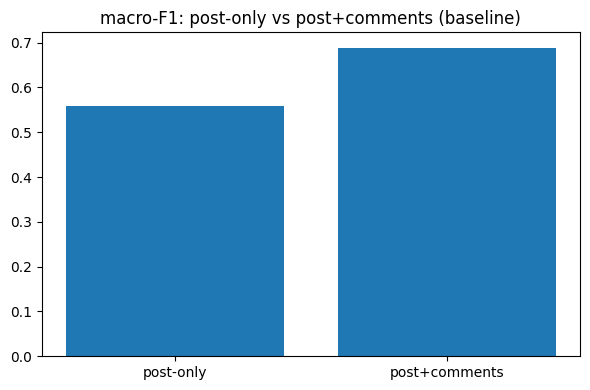

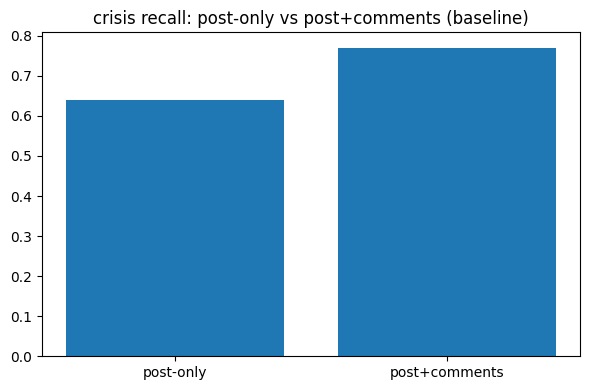

In [5]:
# Visual: metric comparison (post-only vs context)
plt.figure(figsize=(6,4))
plt.bar(["post-only","post+comments"], [m_f1_post, m_f1_ctx])
plt.title("macro-F1: post-only vs post+comments (baseline)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.bar(["post-only","post+comments"], [cri_post, cri_ctx])
plt.title("crisis recall: post-only vs post+comments (baseline)")
plt.tight_layout(); plt.show()


In [ ]:
# ================= FAST + ROBUST triage block (keeps all previous fixes) =================
# - Handles HF 404 on additional_chat_templates via local snapshot fallback
# - Auto-pins a consistent transformers stack if flash-attn import mismatch appears
# - Forces eager attention (no flash-attn)
# - Silences noisy warnings/logs for clean Kaggle runs
# - Speed mode: DistilBERT, max_length=128, dynamic padding, fp16, frozen encoder
# ========================================================================================

bert_scores = {}
if TRAIN_BERT:
    # ---------- 0) Clean output: silence warnings & HF logs ----------
    import warnings, os, sys, subprocess, importlib, json
    warnings.filterwarnings("ignore")  # mute FutureWarnings/UserWarnings, etc.
    os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
    try:
        from transformers.utils.logging import set_verbosity_error
        set_verbosity_error()
    except Exception:
        pass

    # ---------- 1) Ensure a consistent HF stack if flash-attn shim is missing ----------
    def _pin_transformers_stack():
        need_pin = False
        try:
            import transformers  # noqa
            try:
                # This symbol causes the classic mismatch error when the stack is out-of-sync
                from transformers.modeling_flash_attention_utils import lazy_import_flash_attention  # noqa
            except Exception:
                need_pin = True
        except Exception:
            need_pin = True

        if need_pin:
            print("[fix] Aligning HuggingFace stack to avoid flash-attn import mismatch...")
            pkgs = [
                "transformers==4.45.2",
                "huggingface_hub==0.25.2",
                "accelerate==1.1.1",
                "safetensors>=0.4.5",
            ]
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])
            importlib.invalidate_caches()

        import transformers, huggingface_hub  # noqa
        print(f"[env] transformers={transformers.__version__}, hub={huggingface_hub.__version__}")

    _pin_transformers_stack()

    # ---------- 2) Imports after stack sanity ----------
    import numpy as np
    import torch
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import f1_score, recall_score
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        Trainer, TrainingArguments,
        DataCollatorWithPadding
    )

    # Force safe/eager attention; disable flash-attn paths
    os.environ["USE_FLASH_ATTENTION_2"] = "0"
    os.environ["ATTN_IMPLEMENTATION"] = "eager"
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # harmless elsewhere

    # ---------- 3) SPEED toggles (change here if you want) ----------
    USE_BERT   = False  # set True to run full BERT (slower); False uses DistilBERT (faster)
    MODEL_NAME = "google-bert/bert-base-uncased" if USE_BERT else "distilbert-base-uncased"
    MAX_LEN    = 128    # 64–128 is a sweet spot; lower = faster
    EPOCHS     = 1      # quick pass; bump to 2 later if needed
    FREEZE_ENC = True   # train classifier head first (huge speedup)
    USE_FP16   = torch.cuda.is_available()
    BATCH      = 32 if USE_FP16 else 16  # try 32 on GPU; reduce if OOM
    NUM_WORK   = 2

    # ---------- 4) Robust tokenizer load with 404 fallback ----------
    def load_tokenizer(model_id: str):
        try:
            return AutoTokenizer.from_pretrained(model_id, use_fast=True)
        except Exception as e:
            print(f"[warn] Hub tokenizer load failed ({type(e).__name__}): {e}")
            print("[info] Falling back to local snapshot_download to bypass optional chat-templates probe.")
            from huggingface_hub import snapshot_download
            local_dir = snapshot_download(
                repo_id=model_id,
                allow_patterns=[
                    "tokenizer.json", "tokenizer_config.json", "vocab.txt",
                    "config.json", "*.model", "*.vocab", "merges.txt"
                ],
            )
            return AutoTokenizer.from_pretrained(local_dir, local_files_only=True, use_fast=True)

    tokenizer = load_tokenizer(MODEL_NAME)
    collator  = DataCollatorWithPadding(tokenizer=tokenizer)  # dynamic padding => faster

    # ---------- 5) Data split & label encoding (unchanged) ----------
    X_text = df["context_text"].astype(str).values
    y      = df["triage_label"].astype(str).values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_text, y, test_size=0.20, random_state=SEED, stratify=y
    )

    le = LabelEncoder()
    y_tr_enc = le.fit_transform(y_tr)
    y_te_enc = le.transform(y_te)

    id2label = {i: l for i, l in enumerate(le.classes_)}
    label2id = {l: i for i, l in id2label.items()}

    def to_hf_ds(texts, ys):
        return Dataset.from_dict({"text": list(texts), "label": list(ys)})

    train_ds = to_hf_ds(X_tr, y_tr_enc)
    test_ds  = to_hf_ds(X_te,  y_te_enc)

    def tok_fn(batch):
        return tokenizer(batch["text"], truncation=True, padding=False, max_length=MAX_LEN)

    train_tok = train_ds.map(tok_fn, batched=True, desc="Tokenizing train")
    test_tok  = test_ds.map(tok_fn,  batched=True, desc="Tokenizing test")

    cols_keep = ["input_ids", "attention_mask", "label"]
    train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in cols_keep])
    test_tok  = test_tok.remove_columns([c for c in test_tok.column_names if c not in cols_keep])
    train_tok.set_format(type="torch", columns=cols_keep)
    test_tok.set_format(type="torch", columns=cols_keep)

    # ---------- 6) Model load (with eager attention) ----------
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=len(id2label),
            id2label=id2label, label2id=label2id,
            torch_dtype=torch.float32,
            attn_implementation="eager",
        )
    except TypeError:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=len(id2label),
            id2label=id2label, label2id=label2id,
            torch_dtype=torch.float32,
        )
        try:
            model.config._attn_implementation = "eager"
        except Exception:
            pass

    # Optional: freeze encoder for speed (linear probing)
    if FREEZE_ENC:
        base = getattr(model, "distilbert", None) or getattr(model, "bert", None) or getattr(model, "roberta", None)
        if base is not None:
            for p in base.parameters():
                p.requires_grad = False

    # ---------- 7) Training args (quiet + fast) ----------
    args = TrainingArguments(
        output_dir="./o1_fast_triage",
        learning_rate=2e-5,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        dataloader_num_workers=NUM_WORK,
        num_train_epochs=EPOCHS,    # eval once after training
        save_strategy="no",
        logging_steps=500,
        disable_tqdm=True,            # hide progress bars (cleaner/faster display)
        fp16=USE_FP16,                # mixed precision on GPU
        report_to=[],
    )

    # ---------- 8) Metrics (same as before) ----------
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        macro = f1_score(labels, preds, average="macro")
        crisis_id = label2id.get("crisis", None)
        cri = (recall_score((labels == crisis_id), (preds == crisis_id))
               if crisis_id is not None else float("nan"))
        return {"macro_f1": macro, "crisis_recall": cri}

    TOKENIZERS_PARALLELISM=False

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        tokenizer=tokenizer,           # keep for current API; future versions use processing_class
        data_collator=collator,
        compute_metrics=compute_metrics,
    )

    # ---------- 9) Train (fast) & evaluate once ----------
    trainer.train()
    eval_out = trainer.evaluate()

    print_header("FAST triage — eval metrics")
    print(json.dumps(eval_out, indent=2))

    # ---------- 10) Predictions & visuals (unchanged) ----------
    pred_output = trainer.predict(test_tok)
    logits = pred_output.predictions
    preds  = np.argmax(logits, axis=-1)

    y_pred = le.inverse_transform(preds)
    y_true = le.inverse_transform(y_te_enc)

    # Your helpers for visuals
    plot_confusion(y_true, y_pred, title=f"Confusion — {'BERT' if USE_BERT else 'DistilBERT'} (fast)")

    # Stable softmax
    m = logits.max(axis=1, keepdims=True)
    exps = np.exp(logits - m)
    proba = exps / np.clip(exps.sum(axis=1, keepdims=True), 1e-12, None)

    labels = list(le.classes_)
    pr, rc, ap = pr_curve_for_label(y_true, proba, labels, "crisis")
    if pr is not None and rc is not None and ap is not None:
        plot_pr(pr, rc, ap, title_prefix=f"PR — {'BERT' if USE_BERT else 'DistilBERT'} (crisis)")
        plot_calibration(y_true, proba, labels, "crisis",
                         title=f"Calibration — {'BERT' if USE_BERT else 'DistilBERT'} (crisis)")

    # ---------- 11) Export metrics dict ----------
    bert_scores = {
        "macro_f1": float(eval_out.get("eval_macro_f1", eval_out.get("macro_f1", float("nan")))),
        "crisis_recall": float(eval_out.get("eval_crisis_recall", eval_out.get("crisis_recall", float("nan")))),
    }
# ========================================================================================


In [26]:
# ----------------- RQ1 Interpretation -----------------
print_header("RQ1 Interpretation")
msg = [
    "RQ1 asks whether transformer-based models detect early risk with clinically meaningful precision/recall.",
    f"(A) Baseline evidence: context improves performance vs post-only — macro-F1 {m_f1_post:.3f}->{m_f1_ctx:.3f},",
    f"    crisis recall {cri_post:.3f}->{cri_ctx:.3f}.",
    "    Confusion matrices, PR(crisis), calibration, and top n-grams for CRISIS provide transparent evidence.",
]
if TRAIN_BERT and bert_scores:
    msg.append(f"(B) Transformer evidence: BERT macro-F1={bert_scores['macro_f1']:.3f}, crisis recall={bert_scores['crisis_recall']:.3f} on post+comments.")
    msg.append("    If BERT >= baseline (especially on crisis recall) under a stated thresholding policy, RQ1 is supported.")
else:
    msg.append("(B) Transformer evidence: skipped (set TRAIN_BERT=True to include).")
print("\n".join(msg))

# Example thresholding policy (text baseline, post+comments)
# Refit quickly to get proba for policy demo
X_tr, X_te, y_tr, y_te = train_test_split(df["context_text"].values, df["triage_label"].values,
                                          test_size=0.2, random_state=SEED, stratify=df["triage_label"].values)
vec_pol = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=200_000)
Xtr = vec_pol.fit_transform(X_tr); Xte = vec_pol.transform(X_te)
classes = np.unique(y_tr); cw = compute_class_weight("balanced", classes=classes, y=y_tr)
clf_pol = LogisticRegression(solver="saga", multi_class="multinomial", penalty="l2",
                             class_weight={c:w for c,w in zip(classes, cw)},
                             max_iter=3000, n_jobs=1).fit(Xtr, y_tr)

proba = clf_pol.predict_proba(Xte)
labels = clf_pol.classes_.tolist()
p_red    = proba[:, labels.index("red")]    if "red" in labels else np.zeros(len(y_te))
p_crisis = proba[:, labels.index("crisis")] if "crisis" in labels else np.zeros(len(y_te))

# Policy demo: escalate if p(red)>=0.60 or p(crisis)>=0.40
escalate = (p_red >= 0.60) | (p_crisis >= 0.40)
print_header("Operational Policy (demo)")
print(f"Escalate {escalate.mean():.1%} of cases at thresholds p(red)>=0.60 OR p(crisis)>=0.40.")
print("Tune thresholds to your precision/recall targets for moderators.")
# =============================================================================================



RQ1 Interpretation
RQ1 asks whether transformer-based models detect early risk with clinically meaningful precision/recall.
(A) Baseline evidence: context improves performance vs post-only — macro-F1 0.559->0.689,
    crisis recall 0.639->0.770.
    Confusion matrices, PR(crisis), calibration, and top n-grams for CRISIS provide transparent evidence.
(B) Transformer evidence: skipped (set TRAIN_BERT=True to include).

Operational Policy (demo)
Escalate 30.4% of cases at thresholds p(red)>=0.60 OR p(crisis)>=0.40.
Tune thresholds to your precision/recall targets for moderators.
